In [1]:
import xarray as xr
import numpy as np
import colormaps as cmaps

In [2]:
import xarray as xr
import numpy as np
import xarray as xr
from pathlib import Path

BASE_PATH = Path("/projects/prjs2023/chapter3/lpjml_output/2026_04_23_global_droughtexp_10years")

def load_all_runs(file_name, var_name):
    paths = {
        "baseline": BASE_PATH / "baseline/output" / f"{file_name}.nc",
        "MM": BASE_PATH / "MM/output" / f"{file_name}.nc",
        "DM": BASE_PATH / "DM/output" / f"{file_name}.nc",
    }
    
    data = {
        key: xr.open_dataset(path)[var_name]
        for key, path in paths.items()
    }
    
    return data
fpc = load_all_runs("fpc", "FPC")
# process function: skip total PFT (first), spatial mean
def process_fpc_per_pft(data):
    data['pft'] = data['pft'] - 2
    return data.sel(pft=slice(0, 7)).convert_calendar("standard").sel(time=slice("1970", "1979"))

# process all scenarios
fpc_proc = {name: process_fpc_per_pft(ds) for name, ds in fpc.items()}
fpc_proc




{'baseline': <xarray.DataArray 'FPC' (time: 120, pft: 8, lat: 1397, lon: 3600)> Size: 19GB
 [4828032000 values with dtype=float32]
 Coordinates:
   * time     (time) datetime64[ns] 960B 1970-01-16 1970-02-16 ... 1979-12-16
   * pft      (pft) int32 32B 0 1 2 3 4 5 6 7
   * lat      (lat) float64 11kB -55.95 -55.85 -55.75 ... 83.45 83.55 83.65
   * lon      (lon) float64 29kB -179.9 -179.8 -179.8 ... 179.8 179.9 180.0
 Attributes:
     standard_name:  FPC
     long_name:      foliage projected cover,
 'MM': <xarray.DataArray 'FPC' (time: 120, pft: 8, lat: 1397, lon: 3600)> Size: 19GB
 [4828032000 values with dtype=float32]
 Coordinates:
   * time     (time) datetime64[ns] 960B 1970-01-16 1970-02-16 ... 1979-12-16
   * pft      (pft) int32 32B 0 1 2 3 4 5 6 7
   * lat      (lat) float64 11kB -55.95 -55.85 -55.75 ... 83.45 83.55 83.65
   * lon      (lon) float64 29kB -179.9 -179.8 -179.8 ... 179.8 179.9 180.0
 Attributes:
     standard_name:  FPC
     long_name:      foliage projected cov

In [3]:
import numpy as np
import xarray as xr

def time_to_efold(y):
    y = np.asarray(y)

    if not np.isfinite(y[0]) or y[0] <= 0:
        return np.nan

    threshold = y[0] / np.e

    crossed = np.where(y <= threshold)[0]

    if len(crossed) == 0:
        return np.nan

    return crossed[0]  # months since start

tau_baseline = xr.apply_ufunc(
    time_to_efold,
    fpc_proc['baseline'].sel(lon = slice(40,50), lat = slice(60,65)),
    input_core_dims=[["time"]],
    vectorize=True,
    dask="parallelized",
    output_dtypes=[float],
)
tau_baseline


<xarray.DataArray 'FPC' (pft: 8, lat: 50, lon: 100)> Size: 320kB
array([[[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
...
        ...,
        [nan, nan, nan, ..., 72., 60., 72.],
        [nan, nan, nan, ..., 72., 72., 60.],
        [nan, nan, 36., ..., 60., 72., 72.]],

       [[48., 36., 36., ..., 48., 48., 48.],
        [36., 36., 36., ..., 48., 48., 48.],
        [36., 36., 36., ..., 48., 36., 48.],
        ...,
        [nan, nan, nan, ..., 72., 72., 72.],
        [nan, nan, nan, ..., 60., 60., 60.],
        [nan, nan, 48., ..., 60., 72., 60.]],

       [[24., 24., 24., ..., 12., 12., 12.],
        [24., 24., 24., ..., 12., 12., 12.],
        [24., 24., 24., ..., 12., 12., 12.],
        ...,
        [nan, nan, nan, ..., 60., 60., 60.],
        [nan, nan, nan, ..., 60., 60., 60.],
        [nan, nan, 36., ..., 60., 60., 60.]]], shape=(8, 50, 100))
Coordinates:
  * pft      (pft) int32 32B 0 1 2 3 4 5 6 7
  * lat      (lat) float64 400B 60.05 60.15 60.25 60.35 ... 64.75 64.85 64.95
  * lon      (lon) float64 800B 40.05 40.15 40.25 40.35 ... 49.75 49.85 49.95
Attributes:
    standard_name:  FPC
    long_name:      foliage projected cover

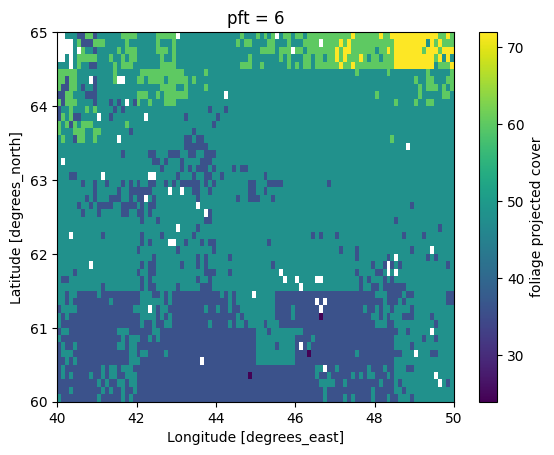

In [15]:
tau_baseline[6].plot()

In [17]:
tau_baseline = xr.open_dataset("/home/druijsch/scripts/2026_06_10_efolding_weighted/tau_baseline.nc").FPC
tau_baseline

<xarray.DataArray 'FPC' (pft: 8, lat: 1397, lon: 3600)> Size: 322MB
[40233600 values with dtype=float64]
Coordinates:
  * pft      (pft) int32 32B 0 1 2 3 4 5 6 7
  * lat      (lat) float64 11kB -55.95 -55.85 -55.75 ... 83.45 83.55 83.65
  * lon      (lon) float64 29kB -179.9 -179.8 -179.8 ... 179.8 179.9 180.0
Attributes:
    standard_name:  FPC
    long_name:      foliage projected cover

In [20]:
FPC0_baseline = (
    fpc_proc["baseline"]
    .isel(time=0)
)
FPC0_baseline

<xarray.DataArray 'FPC' (pft: 8, lat: 1397, lon: 3600)> Size: 161MB
[40233600 values with dtype=float32]
Coordinates:
  * pft      (pft) int32 32B 0 1 2 3 4 5 6 7
  * lat      (lat) float64 11kB -55.95 -55.85 -55.75 ... 83.45 83.55 83.65
  * lon      (lon) float64 29kB -179.9 -179.8 -179.8 ... 179.8 179.9 180.0
    time     datetime64[ns] 8B 1970-01-16
Attributes:
    standard_name:  FPC
    long_name:      foliage projected cover

In [21]:
weights_baseline = FPC0_baseline / FPC0_baseline.sum("pft")
weights_baseline

<xarray.DataArray 'FPC' (pft: 8, lat: 1397, lon: 3600)> Size: 161MB
array([[[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
...
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]]],
      shape=(8, 1397, 3600), dtype=float32)
Coordinates:
  * pft      (pft) int32 32B 0 1 2 3 4 5 6 7
  * lat      (lat) float64 11kB -55.95 -55.85 -55.75 ... 83.45 83.55 83.65
  * lon      (lon) float64 29kB -179.9 -179.8 -179.8 ... 179.8 179.9 180.0
    time     datetime64[ns] 8B 1970-01-16
Attributes:
    standard_name:  FPC
    long_name:      foliage projected cover

In [32]:
tau_weighted_baseline = (tau_baseline * weights_baseline).sum("pft")
total_FPC0_base = FPC0_baseline.sum("pft")
valid = total_FPC0_base > 1e-3 
tau_weighted_baseline = tau_weighted_baseline.where(valid)


tau_weighted_baseline

<xarray.DataArray 'FPC' (lat: 1397, lon: 3600)> Size: 40MB
array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]], shape=(1397, 3600))
Coordinates:
  * lat      (lat) float64 11kB -55.95 -55.85 -55.75 ... 83.45 83.55 83.65
  * lon      (lon) float64 29kB -179.9 -179.8 -179.8 ... 179.8 179.9 180.0
    time     datetime64[ns] 8B 1970-01-16
Attributes:
    standard_name:  FPC
    long_name:      foliage projected cover

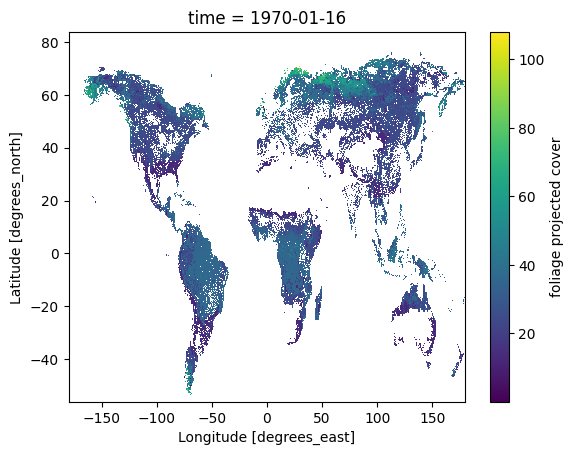

In [33]:
tau_weighted_baseline.where(tau_weighted_baseline > 0).plot()

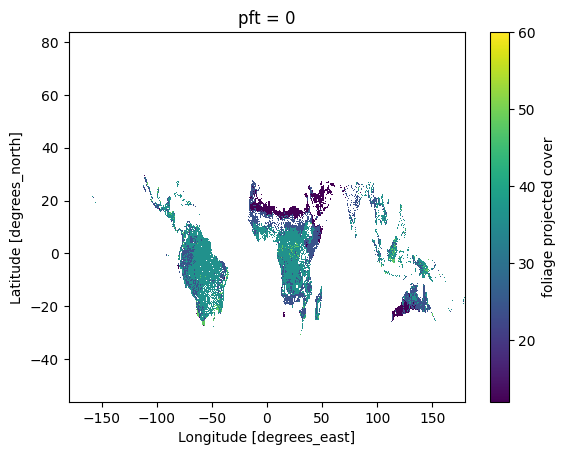

In [18]:
tau_baseline[0].plot()

In [ ]:
import numpy as np
import xarray as xr

FPC = fpc_proc['baseline'].where(fpc_proc['baseline'] > 1e-5)

def fit_tau(y):
    y = np.asarray(y)

    mask = np.isfinite(y) & (y > 0)
    if mask.sum() < 3:
        return np.nan

    t = np.arange(y.shape[0])

    slope, _ = np.polyfit(t[mask], np.log(y[mask]), 1)
    return -1 / slope

tau_base = xr.apply_ufunc(
    fit_tau,
    FPC,
    input_core_dims=[['time']],
    vectorize=True,
    dask='parallelized',
    output_dtypes=[float]
)
tau_base.to_netcdf("/home/druijsch/scripts/2026_05_20_efolding_time_maps/tau_baseline_v4.nc")

In [ ]:


import numpy as np
import xarray as xr

DM = fpc_proc['DM'].where(fpc_proc['DM'] > 1e-3)

def fit_tau(y):
    y = np.asarray(y)

    mask = np.isfinite(y) & (y > 0)
    if mask.sum() < 3:
        return np.nan

    t = np.arange(y.shape[0])

    slope, _ = np.polyfit(t[mask], np.log(y[mask]), 1)
    return -1 / slope

tau_dm = xr.apply_ufunc(
    fit_tau,
    DM,
    input_core_dims=[['time']],
    vectorize=True,
    dask='parallelized',
    output_dtypes=[float]
)
tau_dm.to_netcdf("/home/druijsch/scripts/2026_05_20_efolding_time_maps/tau_dm_v4.nc")

In [2]:
tau_base = xr.open_dataset("/home/druijsch/scripts/2026_05_20_efolding_time_maps/tau_baseline_v4.nc").FPC#.__xarray_dataarray_variable__
tau_DM = xr.open_dataset("/home/druijsch/scripts/2026_05_20_efolding_time_maps/tau_dm_v4.nc").FPC#.__xarray_dataarray_variable__
tau_base

<xarray.DataArray 'FPC' (pft: 8, lat: 1397, lon: 3600)> Size: 322MB
[40233600 values with dtype=float64]
Coordinates:
  * pft      (pft) int32 32B 0 1 2 3 4 5 6 7
  * lat      (lat) float64 11kB -55.95 -55.85 -55.75 ... 83.45 83.55 83.65
  * lon      (lon) float64 29kB -179.9 -179.8 -179.8 ... 179.8 179.9 180.0
Attributes:
    standard_name:  FPC
    long_name:      foliage projected cover

In [3]:
FPC_base = xr.open_dataset("/projects/prjs2023/chapter3/lpjml_output/2026_01_29_baseline_run/baseline_withfire/output/fpc.nc").FPC[-1][1:]
FPC_base['pft'] = FPC_base['pft'] - 2
FPC_base = FPC_base[0:8]


FPC_DM = xr.open_dataset("/projects/prjs2023/chapter3/lpjml_output/2026_04_23_global_droughtmort_new/withfire/output/fpc.nc").FPC[-1][1:]
FPC_DM['pft'] = FPC_DM['pft'] - 2
FPC_DM = FPC_DM[0:8]
FPC_DM

<xarray.DataArray 'FPC' (pft: 8, lat: 1397, lon: 3600)> Size: 161MB
[40233600 values with dtype=float32]
Coordinates:
  * pft      (pft) int32 32B 0 1 2 3 4 5 6 7
  * lat      (lat) float64 11kB -55.95 -55.85 -55.75 ... 83.45 83.55 83.65
  * lon      (lon) float64 29kB -179.9 -179.8 -179.8 ... 179.8 179.9 180.0
    time     object 8B 2019-12-16 00:00:00
Attributes:
    standard_name:  FPC
    long_name:      foliage projected cover

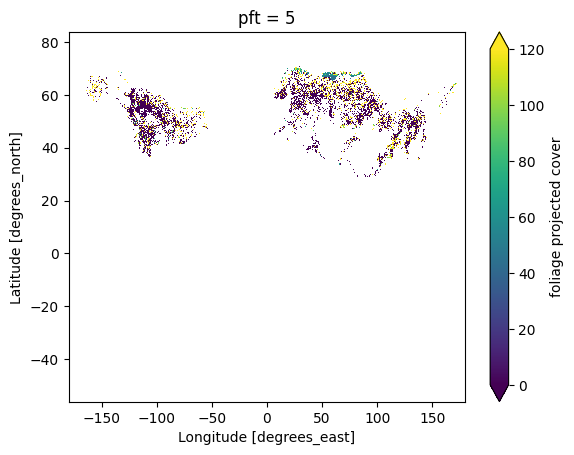

In [19]:
tau_base[5].plot(vmin = 0, vmax = 120)

In [38]:
FPC_base.sel(lon = slice(40,50), lat = slice(60,65))

<xarray.DataArray 'FPC' (pft: 8, lat: 50, lon: 100)> Size: 160kB
array([[[0.000000e+00, 0.000000e+00, ..., 0.000000e+00, 0.000000e+00],
        [0.000000e+00, 0.000000e+00, ..., 0.000000e+00, 0.000000e+00],
        ...,
        [0.000000e+00, 0.000000e+00, ..., 0.000000e+00, 0.000000e+00],
        [         nan,          nan, ..., 0.000000e+00, 0.000000e+00]],

       [[0.000000e+00, 0.000000e+00, ..., 0.000000e+00, 0.000000e+00],
        [0.000000e+00, 0.000000e+00, ..., 0.000000e+00, 0.000000e+00],
        ...,
        [0.000000e+00, 0.000000e+00, ..., 0.000000e+00, 0.000000e+00],
        [         nan,          nan, ..., 0.000000e+00, 0.000000e+00]],

       ...,

       [[1.945371e-02, 1.960983e-02, ..., 1.148297e-02, 1.341073e-02],
        [2.428049e-02, 1.941562e-02, ..., 1.291634e-02, 1.169729e-02],
        ...,
        [0.000000e+00, 0.000000e+00, ..., 4.295619e-05, 3.616293e-05],
        [         nan,          nan, ..., 2.731586e-05, 2.657055e-05]],

       [[3.272742e-02, 3.364626e-02, ..., 5.243599e-02, 5.586689e-02],
        [3.044792e-02, 3.281694e-02, ..., 5.612976e-02, 5.717315e-02],
        ...,
        [0.000000e+00, 0.000000e+00, ..., 7.107761e-04, 2.722695e-03],
        [         nan,          nan, ..., 7.928166e-04, 3.415021e-03]]],
      shape=(8, 50, 100), dtype=float32)
Coordinates:
  * pft      (pft) int32 32B 0 1 2 3 4 5 6 7
  * lat      (lat) float64 400B 60.05 60.15 60.25 60.35 ... 64.75 64.85 64.95
  * lon      (lon) float64 800B 40.05 40.15 40.25 40.35 ... 49.75 49.85 49.95
    time     object 8B 2019-12-16 00:00:00
Attributes:
    standard_name:  FPC
    long_name:      foliage projected cover

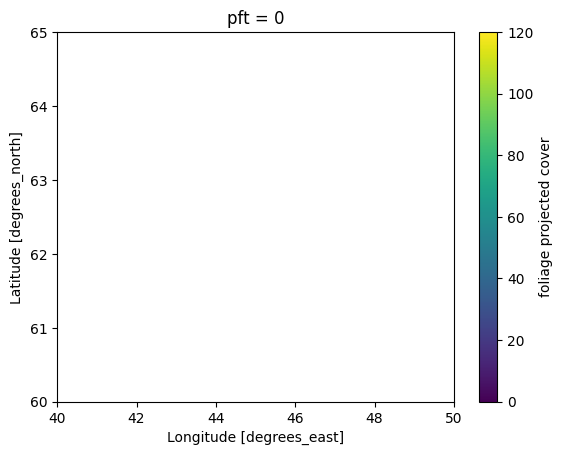

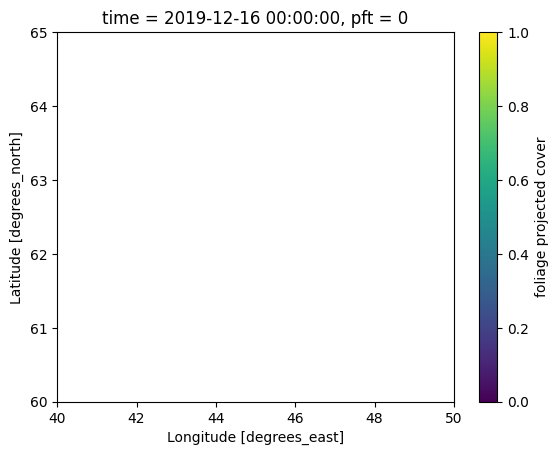

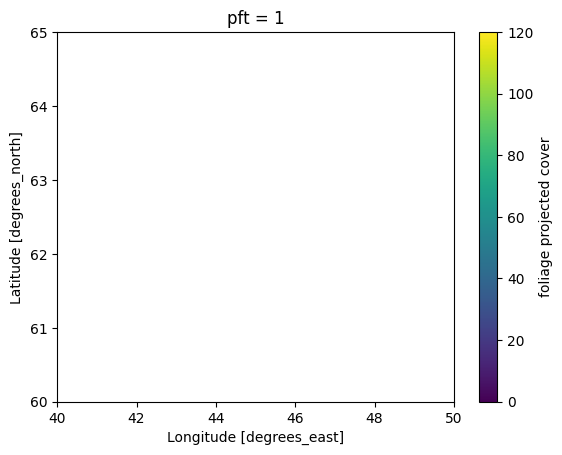

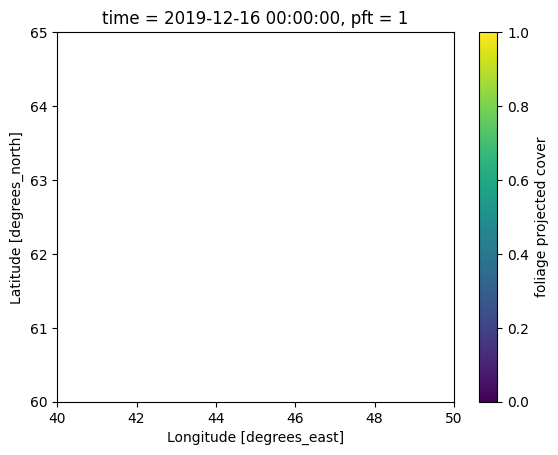

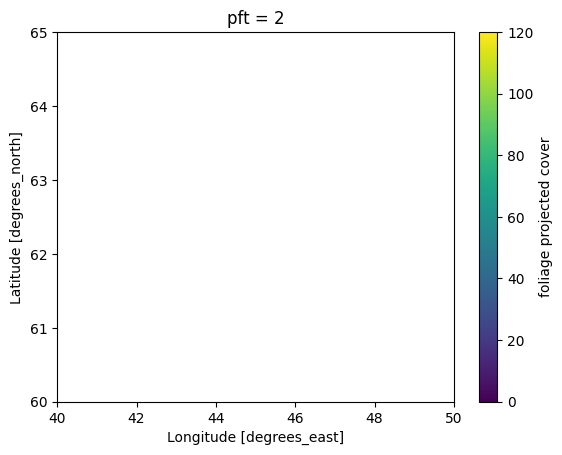

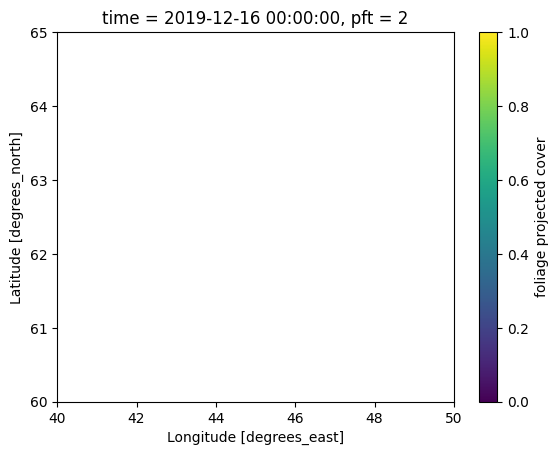

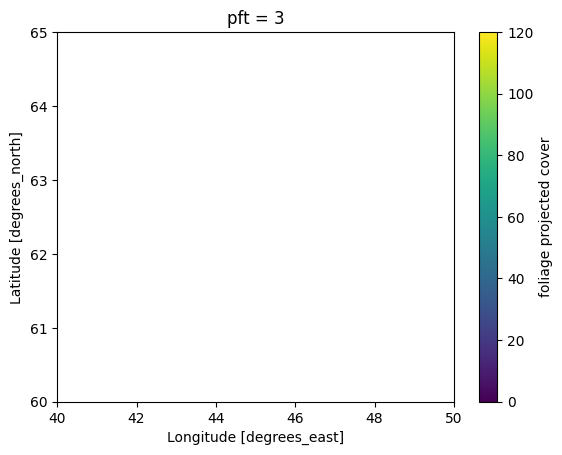

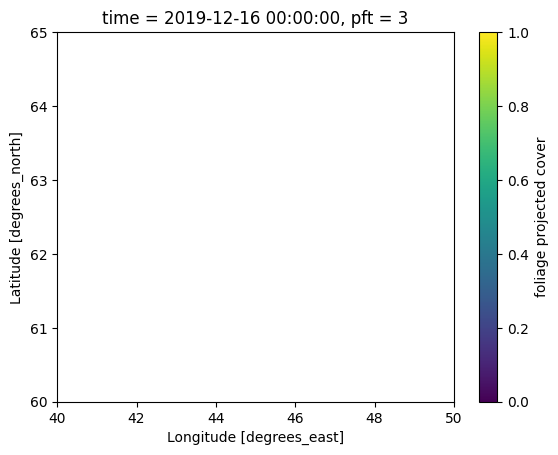

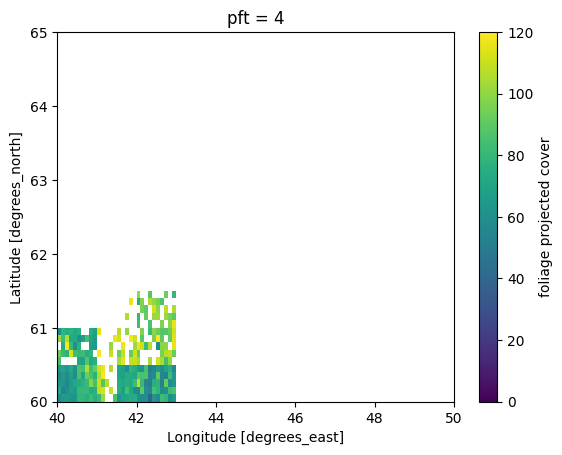

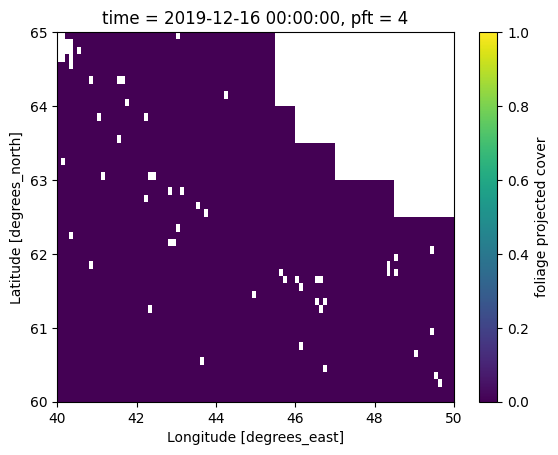

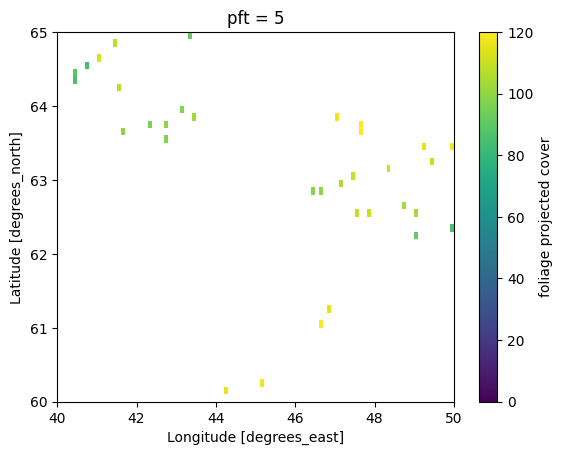

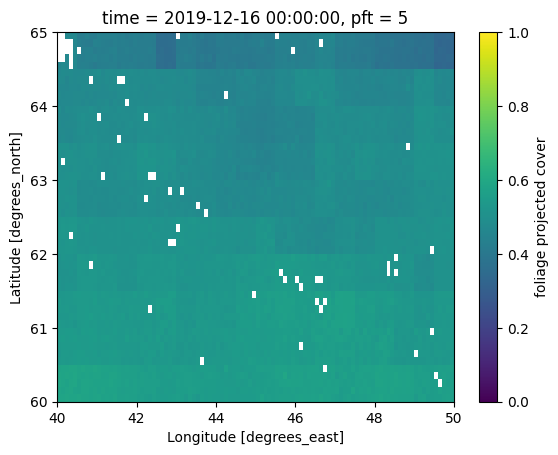

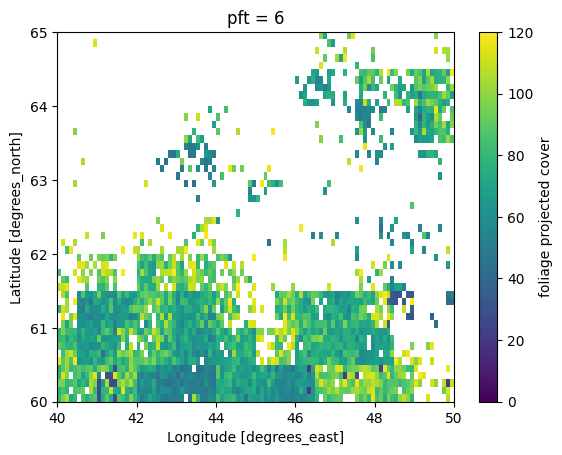

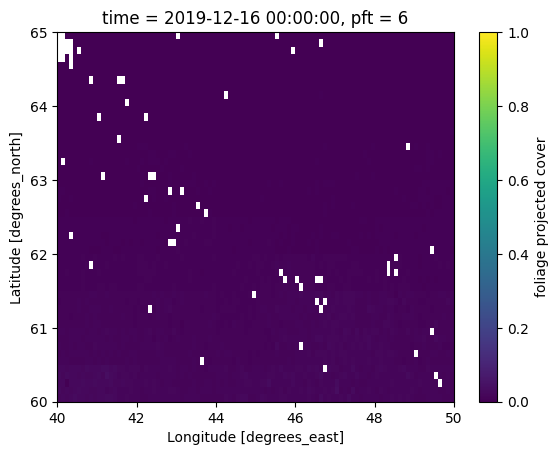

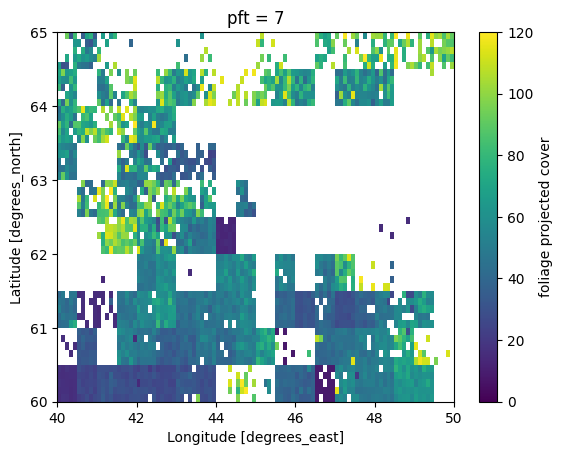

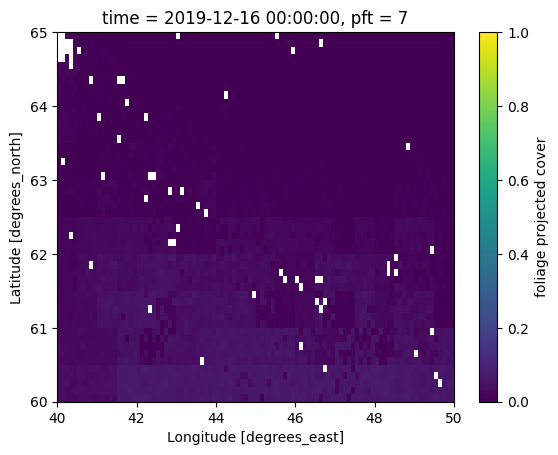

In [ ]:
for i in range(0,8):
    tau_base.where(tau_base < 120).where(tau_base > 0).sel(lon = slice(40,50), lat = slice(60,65))[i].plot(vmin = 0, vmax = 120)
    plt.show()
    FPC_base.where(FPC_base > 0).sel(lon = slice(40,50), lat = slice(60,65))[i].plot(vmin = 0, vmax = 1)
    plt.show()

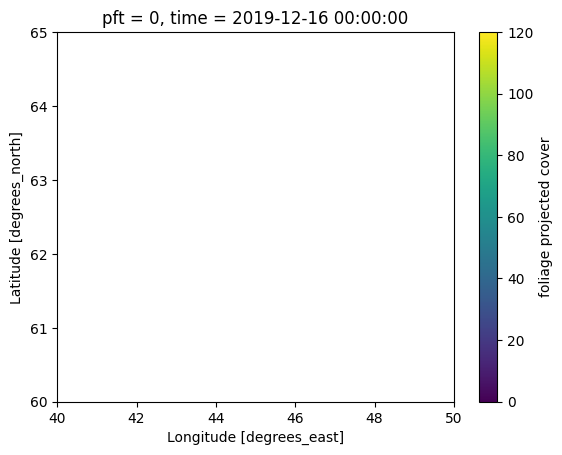

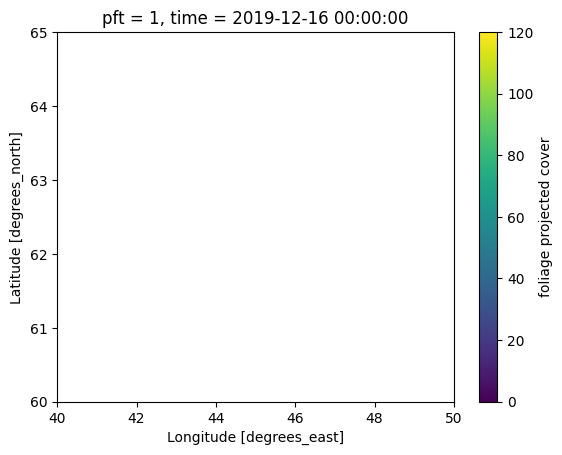

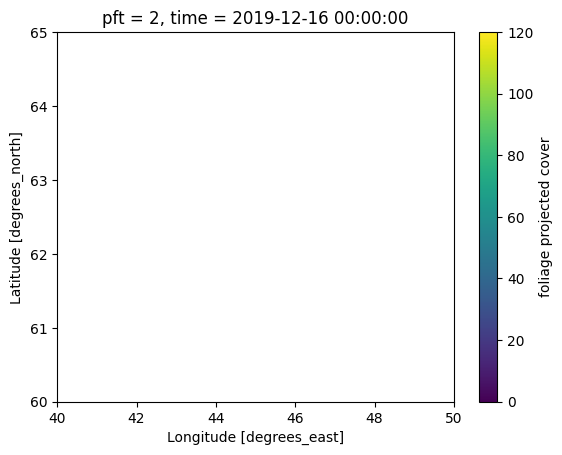

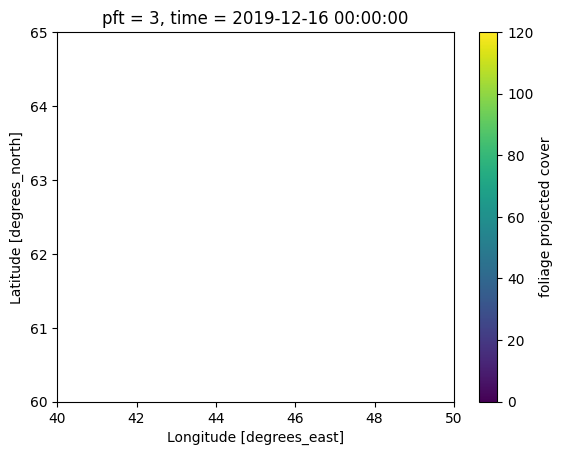

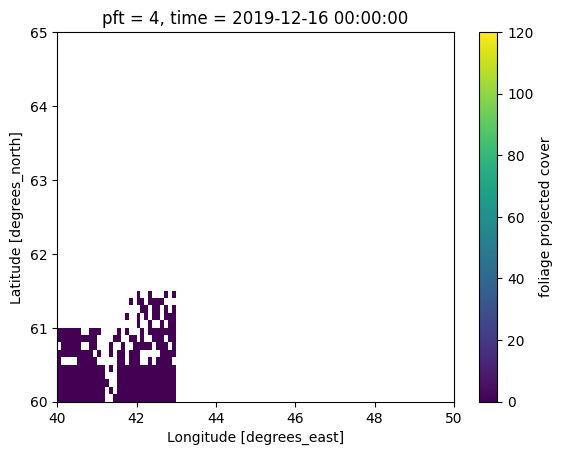

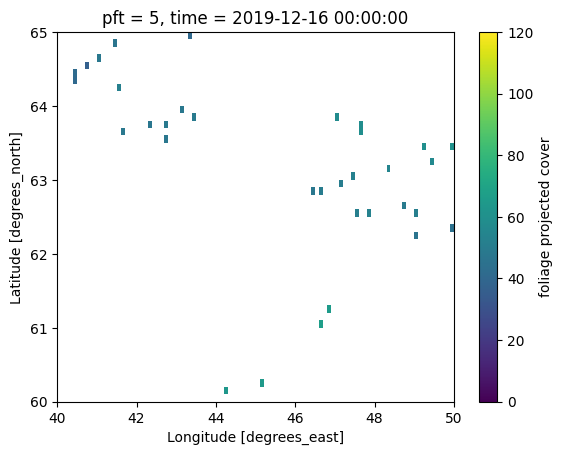

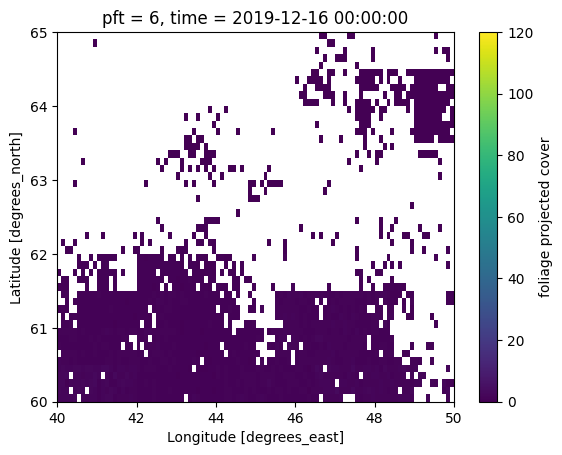

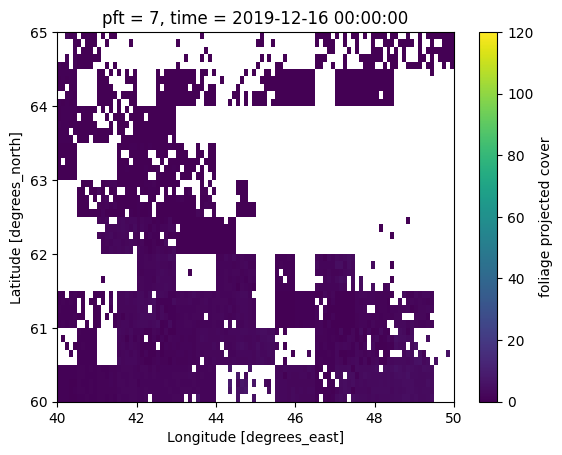

In [40]:
for i in range(0,8):
    (tau_base.where(tau_base < 120).where(tau_base > 0) * FPC_base.where(FPC_base > 0)).sel(lon = slice(40,50), lat = slice(60,65))[i].plot(vmin = 0, vmax = 120)
    plt.show()


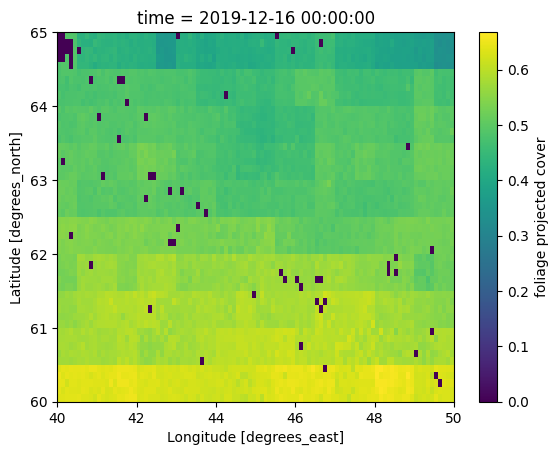

In [42]:
FPC_base.sel(lon = slice(40,50), lat = slice(60,65)).where(FPC_base > 0).sum(dim='pft').plot()

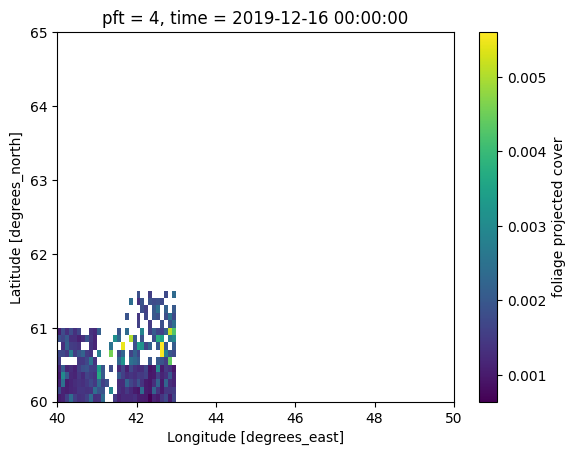

In [49]:
(tau_base.where(tau_base < 120).where(tau_base > 0) * FPC_base.where(FPC_base > 0)).sel(lon = slice(40,50), lat = slice(60,65))[4].plot()

In [ ]:
tau_base_mean_weighted = (tau_base.where(tau_base < 120).where(tau_base > 0) * FPC_base.where(FPC_base > 0)).sum(dim='pft') / FPC_base.where(FPC_base > 0).sum(dim='pft')
tau_DM_mean_weighted = (tau_DM.where(tau_DM < 120).where(tau_DM > 0) * FPC_DM.where(FPC_DM > 0)).sum(dim='pft') / FPC_DM.where(FPC_DM > 0).sum(dim='pft')

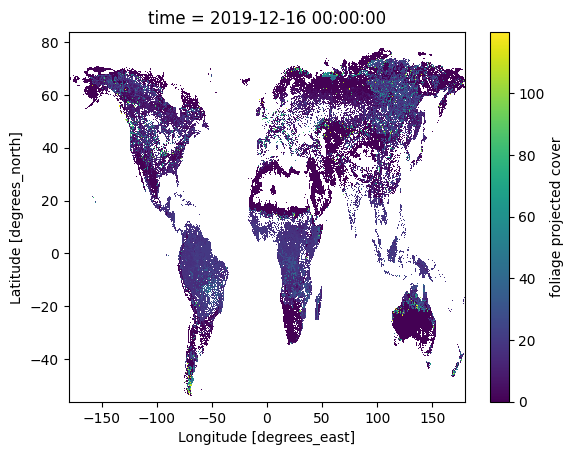

In [26]:
tau_base_mean_weighted.plot()

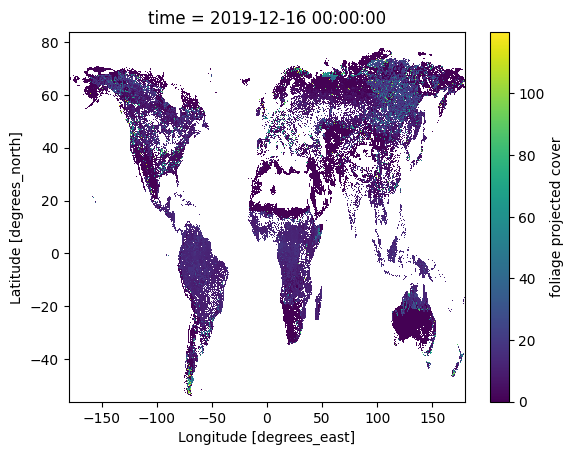

In [27]:
tau_DM_mean_weighted.plot()

/scratch-local/77370/ipykernel_2998804/1869296061.py:3: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_continuous = plt.cm.get_cmap(cmap)


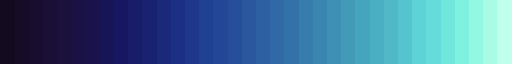

In [7]:
import matplotlib.pyplot as plt
def create_discrete_colormap(cmap, num_colors):
    cmap_continuous = plt.cm.get_cmap(cmap)
    colors_continuous = cmap_continuous(np.linspace(0.03, 1, num_colors))  # Adjusted range, excluding white
    cmap_discrete = plt.matplotlib.colors.ListedColormap(colors_continuous)
    return cmap_discrete

# Example usage:
cmap = create_discrete_colormap(cmaps.blue_bl111, 36)
cmap

/scratch-local/77370/ipykernel_2998804/3130445943.py:3: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_continuous = plt.cm.get_cmap(cmap)


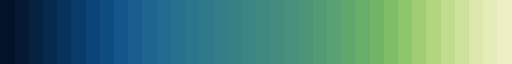

In [8]:
import matplotlib.pyplot as plt
def create_discrete_colormap(cmap, num_colors):
    cmap_continuous = plt.cm.get_cmap(cmap)
    colors_continuous = cmap_continuous(np.linspace(0, 0.95, num_colors))  # Adjusted range, excluding white
    cmap_discrete = plt.matplotlib.colors.ListedColormap(colors_continuous)
    return cmap_discrete

# Example usage:
cmap = create_discrete_colormap(cmaps.navia, 36)
cmap

/scratch-local/77370/ipykernel_2998804/2341216918.py:3: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_continuous = plt.cm.get_cmap(cmap)


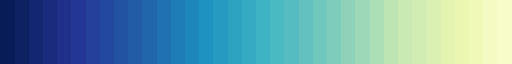

In [9]:
import matplotlib.pyplot as plt
def create_discrete_colormap(cmap, num_colors):
    cmap_continuous = plt.cm.get_cmap(cmap)
    colors_continuous = cmap_continuous(np.linspace(0, 0.95, num_colors))  # Adjusted range, excluding white
    cmap_discrete = plt.matplotlib.colors.ListedColormap(colors_continuous)
    return cmap_discrete

# Example usage:
cmap = create_discrete_colormap("YlGnBu_r", 36)
cmap

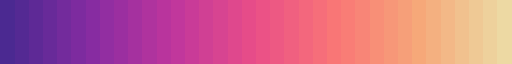

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, ListedColormap
import colormaps as cmaps

# Original 7 colors from agsunset
base_colors = cmaps.agsunset.colors

# Create a continuous interpolated colormap
continuous_cmap = LinearSegmentedColormap.from_list(
    "agsunset_interp",
    base_colors
)

# Sample 36 evenly spaced colors
colors_36 = continuous_cmap(np.linspace(0, 1, 36))

# Convert to a discrete matplotlib colormap
cmap_36 = ListedColormap(colors_36)
cmap_36

In [11]:
cmap = cmap_36
tau_base_mean = tau_base_mean_weighted.where(tau_base_mean_weighted > 0)
tau_DM_mean = tau_DM_mean_weighted.where(tau_DM_mean_weighted > 0)

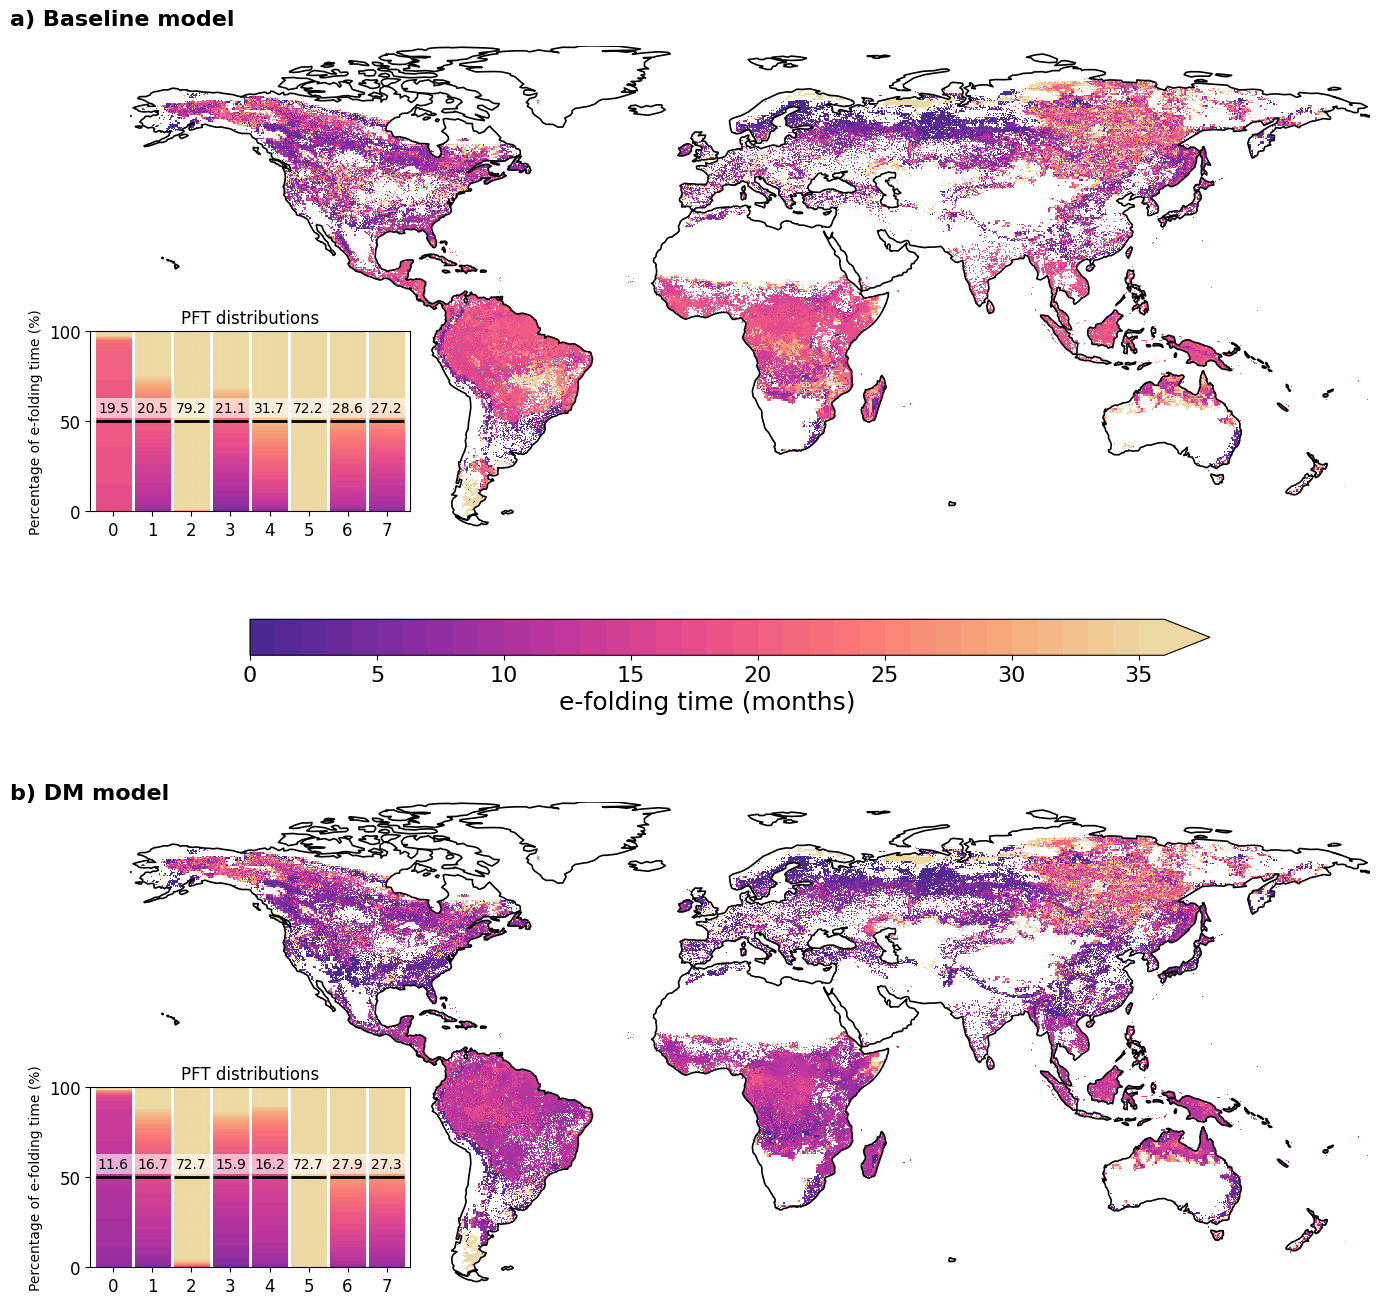

In [12]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import numpy as np

plt.rcParams.update({
    "font.size": 18,
    "axes.titlesize": 22,
    "axes.labelsize": 20,
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
})


# -----------------------------
# Clean data
# -----------------------------
tau_base_clean = tau_base.where((tau_base > 0) & (tau_base < 120))
tau_DM_clean   = tau_DM.where((tau_DM > 0) & (tau_DM < 120))

pft_names = ['trop.EVG', 'trop.RG', 'temp.NE', 'temp.BE', 'temp.BS', 'boreal.NE', 'boreal.BS', 'boreal.NS']

pfts = tau_base_clean['pft'].values

norm = plt.Normalize(0, 36)

# -----------------------------
# Figure (maps)
# -----------------------------
fig, axes = plt.subplots(
    2, 1,
    figsize=(16, 18),
    subplot_kw={'projection': ccrs.PlateCarree(central_longitude=11)}
)

# --- maps ---
tau_base_mean.plot(
    ax=axes[0],
    transform=ccrs.PlateCarree(),
    vmin=0, vmax=36,
    cmap=cmap,
    add_colorbar=False
)

im = tau_DM_mean.plot(
    ax=axes[1],
    transform=ccrs.PlateCarree(),
    vmin=0, vmax=36,
    cmap=cmap,
    add_colorbar=False
)

for ax in axes:
    ax.coastlines(linewidth=1.2)
    ax.set_title("")
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_frame_on(False)
    
    ax.set_xlabel("")
    ax.set_ylabel("")

# -----------------------------
# inset helper
# -----------------------------
def plot_strips(ax, data):
    for i, pft in enumerate(pfts):
        vals = data.sel(pft=pft).values.flatten()
        vals = vals[~np.isnan(vals)]

        if len(vals) == 0:
            continue

        vals_sorted = np.sort(vals)
        strip = vals_sorted[:, None]

        ax.imshow(
            strip,
            aspect='auto',
            cmap=cmap,
            norm=norm,
            extent=(i - 0.45, i + 0.45, 0, 1),
            origin='lower'
        )

        median = np.median(vals_sorted)
        y_med = np.searchsorted(vals_sorted, median) / len(vals_sorted)

        ax.hlines(
            y=y_med,
            xmin=i - 0.45,
            xmax=i + 0.45,
            color='black',
            linewidth=2
        )
        
        # median label
        ax.text(
            i,
            y_med+0.035,
            f"{median:.1f}",
            ha='center',
            va='bottom',
            fontsize=10,  # bigger
            color='black',
            bbox=dict(facecolor='white', alpha=0.6, edgecolor='none', pad=2)
        )

    ax.set_xlim(-0.6, len(pfts) - 0.4)
    ax.set_ylim(0, 1)
    ax.set_yticks([0, 0.5, 1])
    ax.set_yticklabels(["0", "50", "100"], fontsize=12)
    ax.set_xticks(np.arange(len(pfts)))
    ax.set_xticklabels(pfts, fontsize=12)


# -----------------------------
# INSETS (ONE PER MAP)
# -----------------------------

# inset for baseline
inset1 = fig.add_axes([0.1, 0.58, 0.2, 0.1])  # top inset
plot_strips(inset1, tau_base_clean)
inset1.set_title("PFT distributions", fontsize=12)
inset1.set_ylabel("Percentage of e-folding time (%)", fontsize=10)

# inset for drought
inset2 = fig.add_axes([0.1, 0.16, 0.2, 0.1])  # bottom inset
plot_strips(inset2, tau_DM_clean)
inset2.set_title("PFT distributions", fontsize=12)
inset2.set_ylabel("Percentage of e-folding time (%)", fontsize=10)

# -----------------------------
# shared colorbar
# -----------------------------
cbar_ax = fig.add_axes([0.2, 0.5, 0.6, 0.02])
cbar = fig.colorbar(im, cax=cbar_ax, orientation='horizontal', extend = 'max')
cbar.set_label("e-folding time (months)",  fontsize=18)
cbar.ax.tick_params(labelsize=16)

# -----------------------------
# panel labels
# -----------------------------
fig.text(
    0.05, 0.85,
    "a) Baseline model",
    fontsize=16,
    fontweight='bold'
)

fig.text(
    0.05, 0.42,
    "b) DM model",
    fontsize=16,
    fontweight='bold'
)

# # -----------------------------
# # styling
# # -----------------------------
# fig.patch.set_alpha(0)
# for ax in axes:
#     ax.set_facecolor("none")

# inset1.set_facecolor("none")
# inset2.set_facecolor("none")

plt.savefig(
    "/home/druijsch/scripts/2026_06_10_efolding_weighted/tau_maps_with_two_insets_weighted_pink.png",
    dpi=300,
    bbox_inches="tight"
    # transparent=True
)

plt.show()

/scratch-local/77370/ipykernel_2296201/2341216918.py:3: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_continuous = plt.cm.get_cmap(cmap)


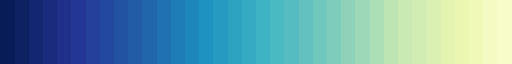

In [13]:
import matplotlib.pyplot as plt
def create_discrete_colormap(cmap, num_colors):
    cmap_continuous = plt.cm.get_cmap(cmap)
    colors_continuous = cmap_continuous(np.linspace(0, 0.95, num_colors))  # Adjusted range, excluding white
    cmap_discrete = plt.matplotlib.colors.ListedColormap(colors_continuous)
    return cmap_discrete

# Example usage:
cmap = create_discrete_colormap("YlGnBu_r", 36)
cmap

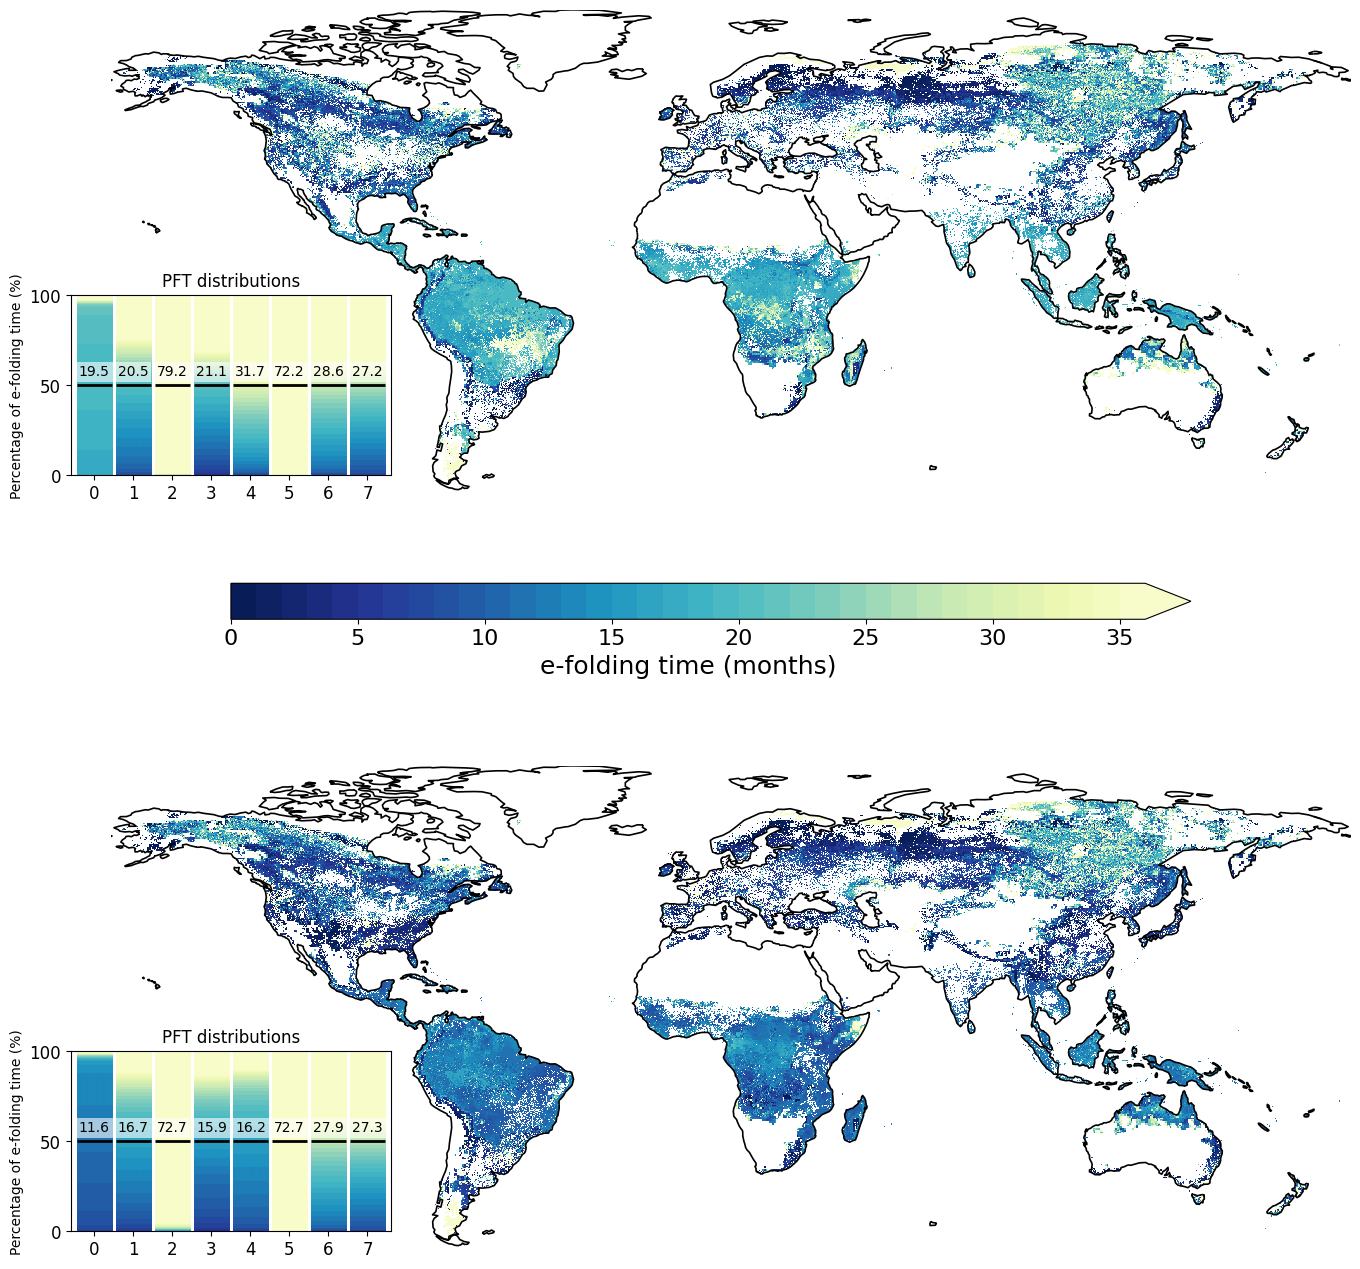

In [14]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import numpy as np

plt.rcParams.update({
    "font.size": 18,
    "axes.titlesize": 22,
    "axes.labelsize": 20,
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
})


# -----------------------------
# Clean data
# -----------------------------
tau_base_clean = tau_base.where((tau_base > 0) & (tau_base < 120))
tau_DM_clean   = tau_DM.where((tau_DM > 0) & (tau_DM < 120))

pft_names = ['trop.EVG', 'trop.RG', 'temp.NE', 'temp.BE', 'temp.BS', 'boreal.NE', 'boreal.BS', 'boreal.NS']

pfts = tau_base_clean['pft'].values

norm = plt.Normalize(0, 36)

# -----------------------------
# Figure (maps)
# -----------------------------
fig, axes = plt.subplots(
    2, 1,
    figsize=(16, 18),
    subplot_kw={'projection': ccrs.PlateCarree(central_longitude=11)}
)

# --- maps ---
tau_base_mean.plot(
    ax=axes[0],
    transform=ccrs.PlateCarree(),
    vmin=0, vmax=36,
    cmap=cmap,
    add_colorbar=False
)

im = tau_DM_mean.plot(
    ax=axes[1],
    transform=ccrs.PlateCarree(),
    vmin=0, vmax=36,
    cmap=cmap,
    add_colorbar=False
)

for ax in axes:
    ax.coastlines(linewidth=1.2)
    ax.set_title("")
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_frame_on(False)
    
    ax.set_xlabel("")
    ax.set_ylabel("")

# -----------------------------
# inset helper
# -----------------------------
def plot_strips(ax, data):
    for i, pft in enumerate(pfts):
        vals = data.sel(pft=pft).values.flatten()
        vals = vals[~np.isnan(vals)]

        if len(vals) == 0:
            continue

        vals_sorted = np.sort(vals)
        strip = vals_sorted[:, None]

        ax.imshow(
            strip,
            aspect='auto',
            cmap=cmap,
            norm=norm,
            extent=(i - 0.45, i + 0.45, 0, 1),
            origin='lower'
        )

        median = np.median(vals_sorted)
        y_med = np.searchsorted(vals_sorted, median) / len(vals_sorted)

        ax.hlines(
            y=y_med,
            xmin=i - 0.45,
            xmax=i + 0.45,
            color='black',
            linewidth=2
        )
        
        # median label
        ax.text(
            i,
            y_med+0.035,
            f"{median:.1f}",
            ha='center',
            va='bottom',
            fontsize=10,  # bigger
            color='black',
            bbox=dict(facecolor='white', alpha=0.6, edgecolor='none', pad=2)
        )

    ax.set_xlim(-0.6, len(pfts) - 0.4)
    ax.set_ylim(0, 1)
    ax.set_yticks([0, 0.5, 1])
    ax.set_yticklabels(["0", "50", "100"], fontsize=12)
    ax.set_xticks(np.arange(len(pfts)))
    ax.set_xticklabels(pfts, fontsize=12)


# -----------------------------
# INSETS (ONE PER MAP)
# -----------------------------

# inset for baseline
inset1 = fig.add_axes([0.1, 0.58, 0.2, 0.1])  # top inset
plot_strips(inset1, tau_base_clean)
inset1.set_title("PFT distributions", fontsize=12)
inset1.set_ylabel("Percentage of e-folding time (%)", fontsize=10)

# inset for drought
inset2 = fig.add_axes([0.1, 0.16, 0.2, 0.1])  # bottom inset
plot_strips(inset2, tau_DM_clean)
inset2.set_title("PFT distributions", fontsize=12)
inset2.set_ylabel("Percentage of e-folding time (%)", fontsize=10)

# -----------------------------
# shared colorbar
# -----------------------------
cbar_ax = fig.add_axes([0.2, 0.5, 0.6, 0.02])
cbar = fig.colorbar(im, cax=cbar_ax, orientation='horizontal', extend = 'max')
cbar.set_label("e-folding time (months)",  fontsize=18)
cbar.ax.tick_params(labelsize=16)

# # -----------------------------
# # styling
# # -----------------------------
# fig.patch.set_alpha(0)
# for ax in axes:
#     ax.set_facecolor("none")

# inset1.set_facecolor("none")
# inset2.set_facecolor("none")

plt.savefig(
    "/home/druijsch/scripts/2026_06_10_efolding_weighted/tau_maps_with_two_insets_weighted_blue.png",
    dpi=300,
    bbox_inches="tight"
    # transparent=True
)

plt.show()

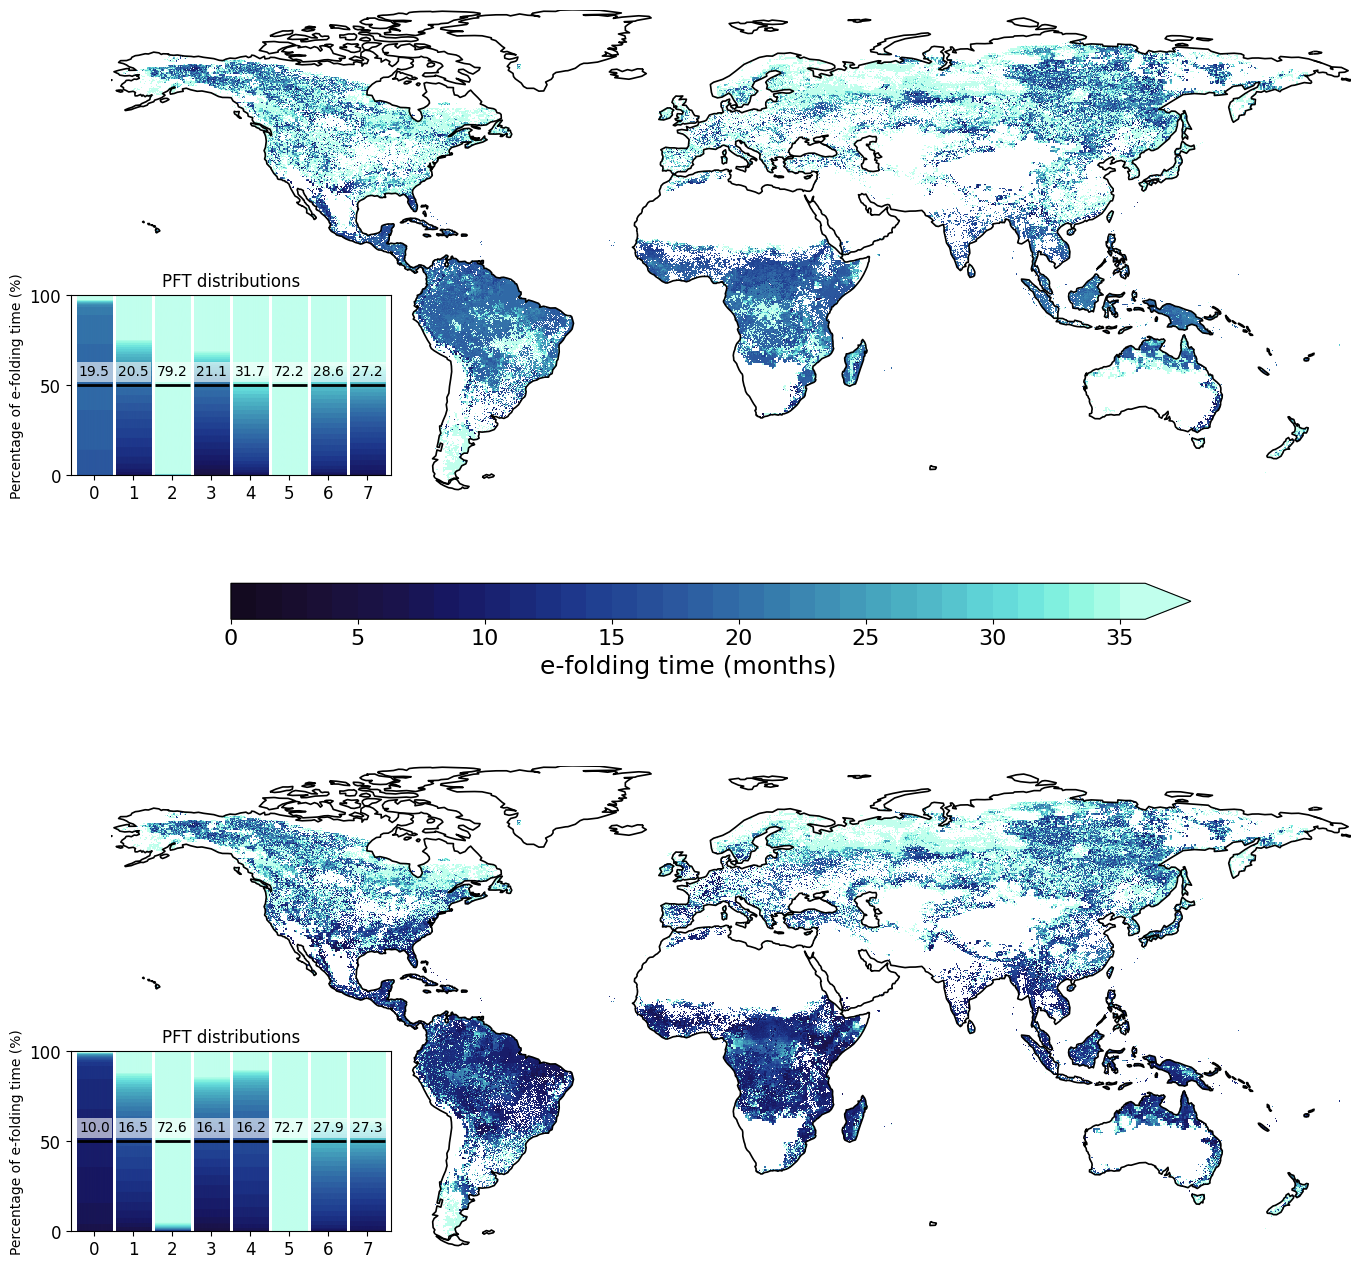

In [ ]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import numpy as np

plt.rcParams.update({
    "font.size": 18,
    "axes.titlesize": 22,
    "axes.labelsize": 20,
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
})


# -----------------------------
# Clean data
# -----------------------------
tau_base_clean = tau_base.where((tau_base > 0) & (tau_base < 120))
tau_DM_clean   = tau_DM.where((tau_DM > 0) & (tau_DM < 120))

pft_names = ['trop.EVG', 'trop.RG', 'temp.NE', 'temp.BE', 'temp.BS', 'boreal.NE', 'boreal.BS', 'boreal.NS']

pfts = tau_base_clean['pft'].values

norm = plt.Normalize(0, 36)

# -----------------------------
# Figure (maps)
# -----------------------------
fig, axes = plt.subplots(
    2, 1,
    figsize=(16, 18),
    subplot_kw={'projection': ccrs.PlateCarree(central_longitude=11)}
)

# --- maps ---
tau_base_mean.plot(
    ax=axes[0],
    transform=ccrs.PlateCarree(),
    vmin=0, vmax=36,
    cmap=cmap,
    add_colorbar=False
)

im = tau_DM_mean.plot(
    ax=axes[1],
    transform=ccrs.PlateCarree(),
    vmin=0, vmax=36,
    cmap=cmap,
    add_colorbar=False
)

for ax in axes:
    ax.coastlines(linewidth=1.2)
    ax.set_title("")
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_frame_on(False)
    
    ax.set_xlabel("")
    ax.set_ylabel("")

# -----------------------------
# inset helper
# -----------------------------
def plot_strips(ax, data):
    for i, pft in enumerate(pfts):
        vals = data.sel(pft=pft).values.flatten()
        vals = vals[~np.isnan(vals)]

        if len(vals) == 0:
            continue

        vals_sorted = np.sort(vals)
        strip = vals_sorted[:, None]

        ax.imshow(
            strip,
            aspect='auto',
            cmap=cmap,
            norm=norm,
            extent=(i - 0.45, i + 0.45, 0, 1),
            origin='lower'
        )

        median = np.median(vals_sorted)
        y_med = np.searchsorted(vals_sorted, median) / len(vals_sorted)

        ax.hlines(
            y=y_med,
            xmin=i - 0.45,
            xmax=i + 0.45,
            color='black',
            linewidth=2
        )
        
        # median label
        ax.text(
            i,
            y_med+0.035,
            f"{median:.1f}",
            ha='center',
            va='bottom',
            fontsize=10,  # bigger
            color='black',
            bbox=dict(facecolor='white', alpha=0.6, edgecolor='none', pad=2)
        )

    ax.set_xlim(-0.6, len(pfts) - 0.4)
    ax.set_ylim(0, 1)
    ax.set_yticks([0, 0.5, 1])
    ax.set_yticklabels(["0", "50", "100"], fontsize=12)
    ax.set_xticks(np.arange(len(pfts)))
    ax.set_xticklabels(pfts, fontsize=12)


# -----------------------------
# INSETS (ONE PER MAP)
# -----------------------------

# inset for baseline
inset1 = fig.add_axes([0.1, 0.58, 0.2, 0.1])  # top inset
plot_strips(inset1, tau_base_clean)
inset1.set_title("PFT distributions", fontsize=12)
inset1.set_ylabel("Percentage of e-folding time (%)", fontsize=10)

# inset for drought
inset2 = fig.add_axes([0.1, 0.16, 0.2, 0.1])  # bottom inset
plot_strips(inset2, tau_DM_clean)
inset2.set_title("PFT distributions", fontsize=12)
inset2.set_ylabel("Percentage of e-folding time (%)", fontsize=10)

# -----------------------------
# shared colorbar
# -----------------------------
cbar_ax = fig.add_axes([0.2, 0.5, 0.6, 0.02])
cbar = fig.colorbar(im, cax=cbar_ax, orientation='horizontal', extend = 'max')
cbar.set_label("e-folding time (months)",  fontsize=18)
cbar.ax.tick_params(labelsize=16)

# # -----------------------------
# # styling
# # -----------------------------
# fig.patch.set_alpha(0)
# for ax in axes:
#     ax.set_facecolor("none")

# inset1.set_facecolor("none")
# inset2.set_facecolor("none")

# plt.savefig(
#     "/home/druijsch/LPJmL5/dev15oct2025/config_files/2026_04_23_global_droughtexp_10years/tau_maps_with_two_insets.png",
#     dpi=300,
#     bbox_inches="tight",
#     transparent=True
# )

plt.show()